In [55]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import numpy as np

# Set the seed for reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

In [56]:
gpus = tf.config.list_physical_devices('GPU')
print("GPU Available:", gpus)
print("cuDNN Enabled:", tf.test.is_built_with_cuda())

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Set the number of intra-op and inter-op threads
NUM_CORES = 8
tf.config.threading.set_intra_op_parallelism_threads(NUM_CORES)
tf.config.threading.set_inter_op_parallelism_threads(NUM_CORES)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
cuDNN Enabled: True


### Set up data

In [57]:
import tensorflow as tf
import numpy as np

# --- 1. Load the original MNIST data ---
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocess the images (normalize and add channel dimension)
def preprocess_images(images):
    images = np.expand_dims(images.astype('float32') / 255.0, axis=-1)
    return images

x_train_full = preprocess_images(x_train_full)
x_test = preprocess_images(x_test)

# --- 2. Create the Labeled and Unlabeled Split ---
num_labels = 100
num_classes = 10
x_labeled = []
y_labeled = []
x_unlabeled = []
y_unlabeled = []

# Ensure we have a balanced set of 10 examples for each class
for i in range(num_classes):
    class_indices = np.where(y_train_full == i)[0]
    # Take the first 10 images for the labeled set
    labeled_indices = class_indices[:num_labels // num_classes]
    # Take the rest for the unlabeled set
    unlabeled_indices = class_indices[num_labels // num_classes:]
    
    x_labeled.append(x_train_full[labeled_indices])
    y_labeled.append(y_train_full[labeled_indices])
    x_unlabeled.append(x_train_full[unlabeled_indices])
    y_unlabeled.append(y_train_full[unlabeled_indices])

# Concatenate the lists into numpy arrays
x_labeled = np.concatenate(x_labeled, axis=0)
y_labeled = np.concatenate(y_labeled, axis=0)
x_unlabeled = np.concatenate(x_unlabeled, axis=0)
y_unlabeled = np.concatenate(y_unlabeled, axis=0) # We keep this for validation if needed

print(f"Labeled training examples: {x_labeled.shape[0]}")
print(f"Unlabeled training examples: {x_unlabeled.shape[0]}")

# --- 3. Create tf.data.Dataset objects ---
BATCH_SIZE = 128 # The paper uses a batch size of 100

# Create the labeled dataset. We repeat it so we can draw from it indefinitely.
labeled_train_ds = tf.data.Dataset.from_tensor_slices((x_labeled, y_labeled))
labeled_train_ds = labeled_train_ds.shuffle(buffer_size=num_labels).repeat().batch(BATCH_SIZE)

# Create the unlabeled dataset. We use a dummy label of -1.
unlabeled_train_ds = tf.data.Dataset.from_tensor_slices((x_unlabeled, np.full(y_unlabeled.shape, -1)))
unlabeled_train_ds = unlabeled_train_ds.shuffle(buffer_size=x_unlabeled.shape[0]).batch(BATCH_SIZE)

# Create the test dataset for final evaluation
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(BATCH_SIZE)

# For the training step, we'll zip the two datasets together
# This creates a dataset that yields one batch of labeled data and one batch of unlabeled data at each step
train_ds = tf.data.Dataset.zip((labeled_train_ds, unlabeled_train_ds))

Labeled training examples: 100
Unlabeled training examples: 59900


In [58]:
from tensorflow.keras import layers, Model

# --- Dynamic Hyperparameters ---
# We get the image shape directly from the data we loaded in Step 1
image_shape = image_shape = (28, 28, 1)
latent_dim_a = 50
latent_dim_z = 50


# =============================================================
# Encoder 1: Auxiliary Inference Model q(a|x) - Class Version
# =============================================================
# class Encoder_q_a_x(Model):
#     """Maps an input image x to the parameters of the distribution for a."""
#     def __init__(self, latent_dim, name='q_a_x_encoder', **kwargs):
#         super().__init__(name=name, **kwargs)
#         # Define the layers of the network
#         self.conv1 = layers.Conv2D(32, 3, strides=2, padding='same')
#         self.bn1 = layers.BatchNormalization() # NEW
#         self.conv2 = layers.Conv2D(64, 3, strides=2, padding='same')
#         self.bn2 = layers.BatchNormalization() # NEW
#         self.conv3 = layers.Conv2D(128, 3, strides=1, padding='same')
#         self.bn3 = layers.BatchNormalization() # NEW
#         self.flatten = layers.Flatten()
#         self.dense = layers.Dense(256)
#         self.bn_dense = layers.BatchNormalization() # NEW
#         self.leaky_relu = layers.LeakyReLU(alpha=0.2)
#         self.mu_a_layer = layers.Dense(latent_dim, name='mu_a')
#         self.log_var_a_layer = layers.Dense(latent_dim, name='log_var_a')

#     def call(self, x):
#         # Define the forward pass
#         h = self.bn1(self.conv1(x))
#         h = self.leaky_relu(h)
#         h = self.bn2(self.conv2(h))
#         h = self.leaky_relu(h)
#         h = self.bn3(self.conv3(h))
#         h = self.leaky_relu(h)
#         h = self.flatten(h)
#         h = self.bn_dense(self.dense(h))
#         h = self.leaky_relu(h)
#         mu_a = self.mu_a_layer(h)
#         log_var_a = self.log_var_a_layer(h)
#         return mu_a, log_var_a

# =============================================================
# Encoder 2: Latent Inference Model q(z|x, a) - Class Version
# =============================================================
class Encoder_q_z_xa(Model):
    """Maps an image x AND an auxiliary 'a' to the parameters for z."""
    def __init__(self, latent_dim, name='q_z_xa_encoder', **kwargs):
        super().__init__(name=name, **kwargs)
        # Define layers for processing the image 'x'
        self.conv1 = layers.Conv2D(32, 3, strides=2, padding='same')
        self.bn1 = layers.BatchNormalization() # NEW
        self.conv2 = layers.Conv2D(64, 3, strides=2, padding='same')
        self.bn2 = layers.BatchNormalization() # NEW
        self.conv3 = layers.Conv2D(128, 3, strides=1, padding='same')
        self.bn3 = layers.BatchNormalization() # NEW

        self.flatten = layers.Flatten()
        # Define layers for the combined path
        self.dense1 = layers.Dense(256)
        self.bn_dense = layers.BatchNormalization() # NEW
        self.leaky_relu = layers.LeakyReLU(alpha=0.2)  

        self.mu_z_layer = layers.Dense(latent_dim, name='mu_z')
        self.log_var_z_layer = layers.Dense(latent_dim, name='log_var_z')

    def call(self, inputs):
        # The 'inputs' will be a list: [image_x, variable_a]
        x, a = inputs
        # Process 'x' through its layers
        h_x = self.bn1(self.conv1(x))
        h_x = self.leaky_relu(h_x)
        h_x = self.bn2(self.conv2(h_x))
        h_x = self.leaky_relu(h_x)
        h_x = self.bn3(self.conv3(h_x))
        h_x = self.leaky_relu(h_x)
        h_x = self.flatten(h_x)        
        # Concatenate the processed image features with the input 'a'
        h_concat = layers.concatenate([h_x, a])
        # Run the combined features through the final layers
        h = self.bn_dense(self.dense1(h_concat))
        h = self.leaky_relu(h)
        mu_z = self.mu_z_layer(h)
        log_var_z = self.log_var_z_layer(h)
        return mu_z, log_var_z

# --- Instantiate and Build the Encoders ---
# q_a_x_model = Encoder_q_a_x(latent_dim=latent_dim_a)
q_z_xa_model = Encoder_q_z_xa(latent_dim=latent_dim_z)

# To print the summary, we need to "build" the models by passing a sample input.
# This lets Keras know the input shape and connect all the layers.
dummy_x = tf.zeros((BATCH_SIZE, *image_shape))
dummy_a = tf.zeros((BATCH_SIZE, latent_dim_a))

# Calling the models on dummy data to build them
# _ = q_a_x_model(dummy_x)
_ = q_z_xa_model([dummy_x, dummy_a])

# print("--- Encoder q(a|x) Summary ---")
# q_a_x_model.summary()

print("\n--- Encoder q(z|x, a) Summary ---")
q_z_xa_model.summary()


--- Encoder q(z|x, a) Summary ---


/home/nicolas/Documentos/UTN/INA/giar_ina_dev/.venv/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "q_z_xa_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_38 (Conv2D)              │ (128, 14, 14, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_103         │ (128, 14, 14, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (128, 7, 7, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_104         │ (128, 7, 7, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (128, 7, 7, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_105         │ (128, 7, 7, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_23 (Flatten)            │ (128, 6272)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (128, 256)             │     1,618,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_106         │ (128, 256)             │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_28 (LeakyReLU)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mu_z (Dense)                    │ (128, 50)              │        12,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_var_z (Dense)               │ (128, 50)              │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,980 (6.63 MB)

 Trainable params: 1,738,020 (6.63 MB)

 Non-trainable params: 960 (3.75 KB)

In [59]:
from tensorflow.keras import layers, Model

# =============================================================
# Decoder 1: Main Generative Model p(x|z) - Class Version
# =============================================================
class Decoder_p_x_z(Model):
    """Generates an image x from a latent variable z."""
    def __init__(self, image_shape, name='p_x_z_decoder', **kwargs):
        super().__init__(name=name, **kwargs)
        # We start by projecting and reshaping the latent z
        # The target shape is the shape of the output of the last conv layer in the encoder
        self.dense = layers.Dense(7 * 7 * 128)
        self.bn_dense = layers.BatchNormalization() # NEW
        self.reshape = layers.Reshape((7, 7, 128))
        
        # Then we use transposed convolutions to upsample back to the image shape
        self.conv_transpose1 = layers.Conv2DTranspose(128, 3, strides=1, padding='same')
        self.bn1 = layers.BatchNormalization() # NEW
        self.conv_transpose2 = layers.Conv2DTranspose(64, 3, strides=2, padding='same')
        self.bn2 = layers.BatchNormalization() # NEW
        self.conv_transpose3 = layers.Conv2DTranspose(32, 3, strides=2, padding='same')
        self.bn3 = layers.BatchNormalization() # NEW

        self.leaky_relu = layers.LeakyReLU(alpha=0.2)
        # It has 1 filter (for grayscale) and a sigmoid activation for pixel values [0, 1]
        self.conv_transpose_out = layers.Conv2DTranspose(image_shape[-1], 3, strides=1, padding='same', activation='sigmoid')


    def call(self, z):
        h = self.bn_dense(self.dense(z))
        h = self.leaky_relu(h)
        h = self.reshape(h)
        h = self.bn1(self.conv_transpose1(h))
        h = self.leaky_relu(h)
        h = self.bn2(self.conv_transpose2(h))
        h = self.leaky_relu(h)
        h = self.bn3(self.conv_transpose3(h))
        h = self.leaky_relu(h)
        x_reconstructed = self.conv_transpose_out(h)
        return x_reconstructed

# =============================================================
# Decoder 2: Auxiliary Generative Model p(a|z,x) - Class Version
# =============================================================
class Decoder_p_a_zx(Model):
    """Predicts parameters for 'a' from a latent 'z' and an image 'x'."""
    def __init__(self, latent_dim, name='p_a_zx_decoder', **kwargs):
        super().__init__(name=name, **kwargs)
        self.flatten = layers.Flatten()
        self.dense1 = layers.Dense(256)
        self.bn1 = layers.BatchNormalization() # NEW
        self.dense2 = layers.Dense(256)
        self.bn2 = layers.BatchNormalization() # NEW
        self.dense3 = layers.Dense(256)
        self.bn3 = layers.BatchNormalization() # NEW
        self.leaky_relu = layers.LeakyReLU(alpha=0.2) # NEW ACTIVATION

        # This decoder also outputs a distribution's parameters
        self.mu_a_pred_layer = layers.Dense(latent_dim, name='mu_a_pred')
        self.log_var_a_pred_layer = layers.Dense(latent_dim, name='log_var_a_pred')

    def call(self, inputs):
        z, x = inputs
        # We flatten the image x to combine it with z
        x_flat = self.flatten(x)
        # Concatenate and pass through dense layers
        h_concat = layers.concatenate([z, x_flat])

        h = self.bn1(self.dense1(h_concat))
        h = self.leaky_relu(h)
        h = self.bn2(self.dense2(h))
        h = self.leaky_relu(h)
        h = self.bn3(self.dense3(h))
        h = self.leaky_relu(h)
        
        mu_a_pred = self.mu_a_pred_layer(h)
        log_var_a_pred = self.log_var_a_pred_layer(h)
        return mu_a_pred, log_var_a_pred

# --- Instantiate and Build the Decoders ---
p_x_z_model = Decoder_p_x_z(image_shape)
p_a_zx_model = Decoder_p_a_zx(latent_dim=latent_dim_a)

# Build the models by passing sample inputs
dummy_z = tf.zeros((BATCH_SIZE, latent_dim_z))
# The dummy_x for the p_a_zx_model is the original image, not flattened yet
dummy_x = tf.zeros((BATCH_SIZE, *image_shape))

_ = p_x_z_model(dummy_z)
_ = p_a_zx_model([dummy_z, dummy_x])

print("--- Decoder p(x|z) Summary ---")
p_x_z_model.summary()

print("\n--- Decoder p(a|z,x) Summary ---")
p_a_zx_model.summary()

--- Decoder p(x|z) Summary ---


Model: "p_x_z_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                │ (128, 6272)            │       319,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_107         │ (128, 6272)            │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_9 (Reshape)             │ (128, 7, 7, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_36             │ (128, 7, 7, 128)       │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_108         │ (128, 7, 7, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_37             │ (128, 14, 14, 64)      │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_109         │ (128, 14, 14, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_38             │ (128, 28, 28, 32)      │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_110         │ (128, 28, 28, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_29 (LeakyReLU)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_39             │ (128, 28, 28, 1)       │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 585,985 (2.24 MB)

 Trainable params: 572,993 (2.19 MB)

...

Model: "p_a_zx_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_24 (Flatten)            │ (128, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (128, 256)             │       213,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_111         │ (128, 256)             │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (128, 256)             │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_112         │ (128, 256)             │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (128, 256)             │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_113         │ (128, 256)             │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_30 (LeakyReLU)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mu_a_pred (Dense)               │ (128, 50)              │        12,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_var_a_pred (Dense)          │ (128, 50)              │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 374,116 (1.43 MB)

 Trainable params: 372,580 (1.42 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [60]:
from tensorflow.keras import layers, Model

# =============================================================
# Reparameterization Trick as a Layer
# =============================================================
class Sampling(layers.Layer):
    """
    Uses (mu, log_var) to sample z, the latent vector.
    This is the reparameterization trick.
    """
    def call(self, inputs):
        mu, log_var = inputs
        batch = tf.shape(mu)[0]
        dim = tf.shape(mu)[1]
        # Sample random noise from a standard normal distribution
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        # Compute the sample z = mu + sigma * epsilon
        # Note: sigma = exp(0.5 * log_var)
        return mu + tf.exp(0.5 * log_var) * epsilon

### The Loss Function

In [61]:
class CustomLoss(tf.keras.losses.Loss):
    def __init__(self, y, z, name="custom_loss"):
        super().__init__(name=name)
        # Weights
        self.y = y
        self.z = z

        # MAE
        self.mae_loss_fn = tf.keras.losses.MeanAbsoluteError()

    # SSIM loss
    def ssim_loss(self, y_true, y_pred):
        ssim = (1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))) / 2
        return ssim

    def call(self, y_true, y_pred):
        mae_loss = self.mae_loss_fn(y_true, y_pred)
        ssim = self.ssim_loss(y_true, y_pred)
        return self.y * mae_loss + self.z * ssim
    
def adgm_loss_fn(y_true, y_pred):
    """
    Calculates the ADGM loss as the negative of the Evidence Lower Bound (ELBO).
    """
    # 1. Reconstruction loss for the image x (log p(x|z))
    # We use binary cross-entropy, which is equivalent to the log-probability
    # for a Bernoulli distribution over the pixels.
    recon_loss_x = tf.reduce_mean(tf.reduce_sum(
        tf.keras.losses.binary_crossentropy(y_true, y_pred['x_reconstructed']),
        axis=[1, 2]
    ))

    # custom_recon_loss = CustomLoss(y=0.17, z=0.83)
    # recon_loss_x = custom_recon_loss(y_true, y_pred['x_reconstructed'])
    # recon_loss_x = recon_loss_x * (200 * 200)

    # 2. KL divergence for z (KL[q(z|x,a) || p(z)])
    # This measures how much q(z|x,a) deviates from a standard normal distribution.
    kl_loss_z = tf.reduce_mean(-0.5 * tf.reduce_sum(
        1 + y_pred['log_var_z'] - tf.square(y_pred['mu_z']) - tf.exp(y_pred['log_var_z']),
        axis=1
    ))

    # 3. KL divergence for a (KL[q(a|x) || p(a)])
    # This measures how much q(a|x) deviates from a standard normal distribution.
    kl_loss_a = tf.reduce_mean(-0.5 * tf.reduce_sum(
        1 + y_pred['log_var_a'] - tf.square(y_pred['mu_a']) - tf.exp(y_pred['log_var_a']),
        axis=1
    ))
    
    # 4. Reconstruction loss for a (-log p(a|z,x))
    # This is the negative log-probability of the sampled 'a' under the
    # distribution predicted by the auxiliary decoder.
    log_p_a_zx = -0.5 * tf.reduce_sum(
        tf.square(y_pred['a_sampled'] - y_pred['mu_a_pred']) / tf.exp(y_pred['log_var_a_pred']) + \
        y_pred['log_var_a_pred'] + tf.math.log(2. * np.pi),
        axis=1
    )

    recon_loss_a = tf.reduce_mean(-log_p_a_zx)
    
    total_loss = recon_loss_x + recon_loss_a + kl_loss_z + kl_loss_a
   
    return {
        "loss": total_loss,
        "recon_loss_x": recon_loss_x,
        "recon_loss_a": recon_loss_a,
        "kl_loss_z": kl_loss_z,
        "kl_loss_a": kl_loss_a,
    }

### The model

In [62]:
from tensorflow.keras import layers, Model, losses, metrics

# =============================================================
# The Full Semi-Supervised ADGM Model (Self-Contained)
# =============================================================
class ADGM(Model):
    def __init__(self, latent_dim_a, latent_dim_z, image_shape, num_classes, alpha_weight, name='SS_ADGM', **kwargs):
        super().__init__(name=name, **kwargs)
        self.latent_dim_a = latent_dim_a
        self.latent_dim_z = latent_dim_z
        self.image_shape = image_shape
        self.num_classes = num_classes
        self.alpha = alpha_weight

        # (All the component definitions like shared_encoder, classifier_head, etc. are the same)
        self.shared_encoder = tf.keras.Sequential([
            layers.InputLayer(input_shape=(28, 28, 1)),
            layers.Conv2D(32, 3, strides=2, padding='same', activation='relu'),
            layers.Conv2D(64, 3, strides=2, padding='same', activation='relu'),
            layers.Flatten(), layers.Dense(256, activation='relu')
        ], name='shared_encoder')
        self.classifier_head = layers.Dense(num_classes, name='y_logits')
        self.mu_a_layer = layers.Dense(latent_dim_a, name='mu_a')
        self.log_var_a_layer = layers.Dense(latent_dim_a, name='log_var_a')
        self.q_z_xa_model = Encoder_q_z_xa(latent_dim_z)
        self.p_x_z_model = Decoder_p_x_z(image_shape)
        self.p_a_zx_model = Decoder_p_a_zx(latent_dim_a)
        self.sampling_layer = Sampling()
        
        # --- Loss Functions and Metrics ---
        self.classification_loss_fn = losses.SparseCategoricalCrossentropy(from_logits=True)
        # We no longer need self.unsupervised_loss_fn
        self.total_loss_tracker = metrics.Mean(name="total_loss")
        self.unsupervised_loss_tracker = metrics.Mean(name="unsupervised_loss")
        self.classification_loss_tracker = metrics.Mean(name="classification_loss")
        self.accuracy_tracker = metrics.SparseCategoricalAccuracy(name="accuracy")
        self.kl_a_tracker = metrics.Mean(name="kl_loss_a")
        self.kl_z_tracker = metrics.Mean(name="kl_loss_z")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker, self.unsupervised_loss_tracker,
            self.classification_loss_tracker, self.accuracy_tracker,
            self.kl_a_tracker, self.kl_z_tracker,
        ]

    # --- NEW HELPER METHOD FOR THE LOSS ---
    def _calculate_unsupervised_loss(self, y_true, y_pred):
        recon_loss_x = tf.reduce_mean(tf.reduce_sum(losses.binary_crossentropy(y_true, y_pred['x_reconstructed']), axis=[1, 2]))
        # custom_recon_loss = CustomLoss(y=0.17, z=0.83)
        # recon_loss_x = custom_recon_loss(y_true, y_pred['x_reconstructed'])
        # recon_loss_x = recon_loss_x * (200 * 200)

        kl_loss_z = tf.reduce_mean(-0.5 * tf.reduce_sum(1 + y_pred['log_var_z'] - tf.square(y_pred['mu_z']) - tf.exp(y_pred['log_var_z']), axis=1))
        kl_loss_a = tf.reduce_mean(-0.5 * tf.reduce_sum(1 + y_pred['log_var_a'] - tf.square(y_pred['mu_a']) - tf.exp(y_pred['log_var_a']), axis=1))
        log_p_a_zx = -0.5 * tf.reduce_sum(tf.square(y_pred['a_sampled'] - y_pred['mu_a_pred']) / tf.exp(y_pred['log_var_a_pred']) + y_pred['log_var_a_pred'] + tf.math.log(2. * np.pi), axis=1)
        recon_loss_a = tf.reduce_mean(-log_p_a_zx)
        total_loss = recon_loss_x + recon_loss_a + kl_loss_z + kl_loss_a
        return {"loss": total_loss, "recon_loss_x": recon_loss_x, "recon_loss_a": recon_loss_a, "kl_loss_z": kl_loss_z, "kl_loss_a": kl_loss_a}

    def call(self, x):
        # (call method is unchanged)
        shared_features = self.shared_encoder(x)
        y_logits = self.classifier_head(shared_features)
        mu_a = self.mu_a_layer(shared_features)
        log_var_a = self.log_var_a_layer(shared_features)
        a = self.sampling_layer([mu_a, log_var_a])
        mu_z, log_var_z = self.q_z_xa_model([x, a])
        z = self.sampling_layer([mu_z, log_var_z])
        x_reconstructed = self.p_x_z_model(z)
        mu_a_pred, log_var_a_pred = self.p_a_zx_model([z, x])
        return {
            "mu_a": mu_a, "log_var_a": log_var_a, "a_sampled": a,
            "mu_z": mu_z, "log_var_z": log_var_z, "x_reconstructed": x_reconstructed,
            "mu_a_pred": mu_a_pred, "log_var_a_pred": log_var_a_pred, "y_logits": y_logits
        }

    def train_step(self, data):
        labeled_data, unlabeled_data = data
        x_labeled, y_true = labeled_data
        x_unlabeled, _ = unlabeled_data

        with tf.GradientTape() as tape:
            labeled_outputs = self(x_labeled, training=True)
            unlabeled_outputs = self(x_unlabeled, training=True)
            
            # --- UPDATED: Call the internal helper method ---
            unsupervised_losses_labeled = self._calculate_unsupervised_loss(x_labeled, labeled_outputs)
            unsupervised_losses_unlabeled = self._calculate_unsupervised_loss(x_unlabeled, unlabeled_outputs)
            
            unsupervised_loss_labeled_total = unsupervised_losses_labeled["loss"]
            unsupervised_loss_unlabeled_total = unsupervised_losses_unlabeled["loss"]
            
            classification_loss = self.classification_loss_fn(y_true, labeled_outputs["y_logits"])
            labeled_loss = unsupervised_loss_labeled_total + self.alpha * classification_loss
            total_loss = labeled_loss + unsupervised_loss_unlabeled_total

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        
        self.total_loss_tracker.update_state(total_loss)
        self.unsupervised_loss_tracker.update_state(unsupervised_loss_labeled_total + unsupervised_loss_unlabeled_total)
        self.classification_loss_tracker.update_state(classification_loss)
        self.accuracy_tracker.update_state(y_true, labeled_outputs["y_logits"])
        self.kl_a_tracker.update_state(unsupervised_losses_unlabeled["kl_loss_a"])
        self.kl_z_tracker.update_state(unsupervised_losses_unlabeled["kl_loss_z"])
        
        return {m.name: m.result() for m in self.metrics}
        
    def test_step(self, data):
        # (test_step method is unchanged)
        x, y = data
        outputs = self(x, training=False)
        self.accuracy_tracker.update_state(y, outputs["y_logits"])
        return {"accuracy": self.accuracy_tracker.result()}

### Compiling and Training the Model

In [63]:
# =============================================================
# Training Script
# =============================================================

# --- 1. Configuration ---
LATENT_DIM_A = 50
LATENT_DIM_Z = 50
NUM_CLASSES = 10
EPOCHS = 30
LEARNING_RATE = 1e-4 # A common learning rate for Adam optimizer

# --- 2. Calculate the Alpha Weight ---
# As specified in the paper: alpha = 0.1 * (total dataset size / batch size)
total_train_size = x_labeled.shape[0] + x_unlabeled.shape[0]
print(f"Total training examples: {total_train_size}")
alpha = 0.1 * total_train_size

# --- 3. Instantiate and Compile the Model ---
adgm = ADGM(
    image_shape=image_shape,
    latent_dim_a=LATENT_DIM_A,
    latent_dim_z=LATENT_DIM_Z,
    num_classes=NUM_CLASSES,
    alpha_weight=alpha
)
adgm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE))

# --- 4. Train the Model ---
# The number of steps per epoch is determined by the size of the larger, unlabeled dataset.
steps_per_epoch = x_unlabeled.shape[0] // BATCH_SIZE

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='total_loss', patience=5, verbose=1, mode='min', restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='total_loss', patience=5, verbose=1, factor=0.5, min_lr=1e-6, mode='min', restore_best_weights=True),
]

print("🚀 Starting semi-supervised training...")
history = adgm.fit(
    train_ds,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks,
)

# --- 5. Evaluate Final Performance ---
print("\n✅ Training finished! Evaluating on the test set...")
final_accuracy = adgm.evaluate(test_ds)

/home/nicolas/Documentos/UTN/INA/giar_ina_dev/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Total training examples: 60000
🚀 Starting semi-supervised training...
Epoch 1/30
467/467 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8764 - classification_loss: 0.9673 - kl_loss_a: 5.5417 - kl_loss_z: 23.0589 - total_loss: 6579.1602 - unsupervised_loss: 775.1117 - learning_rate: 1.0000e-04
Epoch 2/30
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 14us/step - accuracy: 1.0000 - classification_loss: 0.0037 - kl_loss_a: 16.9139 - kl_loss_z: 27.1386 - total_loss: 392.1328 - unsupervised_loss: 369.8911 - learning_rate: 1.0000e-04
Epoch 3/30
  7/467 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 1.0000 - classification_loss: 0.0038 - kl_loss_a: 16.7866 - kl_loss_z: 27.6103 - total_loss: 394.7305 - unsupervised_loss: 371.9494

/home/nicolas/Documentos/UTN/INA/giar_ina_dev/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


467/467 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 1.0000 - classification_loss: 0.0025 - kl_loss_a: 20.2702 - kl_loss_z: 27.8410 - total_loss: 370.6476 - unsupervised_loss: 355.9246 - learning_rate: 1.0000e-04
Epoch 4/30
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 13us/step - accuracy: 1.0000 - classification_loss: 7.2439e-04 - kl_loss_a: 29.7002 - kl_loss_z: 29.0267 - total_loss: 333.9566 - unsupervised_loss: 329.6102 - learning_rate: 1.0000e-04
Epoch 5/30
467/467 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 1.0000 - classification_loss: 5.9039e-04 - kl_loss_a: 31.6235 - kl_loss_z: 27.8589 - total_loss: 325.6282 - unsupervised_loss: 322.0859 - learning_rate: 1.0000e-04
Epoch 6/30
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 13us/step - accuracy: 1.0000 - classification_loss: 3.4986e-04 - kl_loss_a: 37.1306 - kl_loss_z: 27.5902 - total_loss: 310.1368 - unsupervised_loss: 308.0377 - learning_rate: 1.0000e-04
Epoch 7/30
467/467 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 1.0000 - classification_loss: 2.70

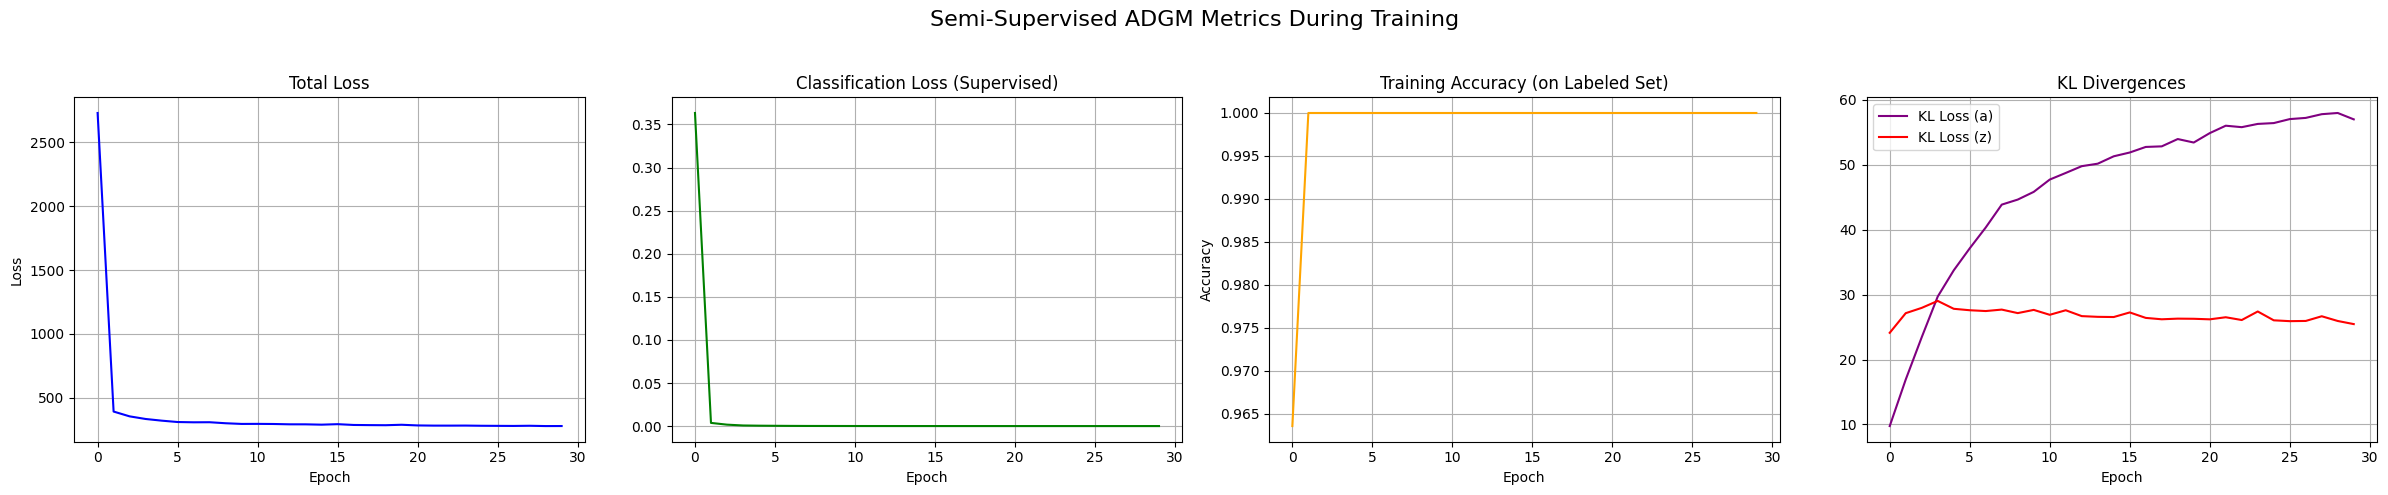

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame from the history object for easier plotting
history_df = pd.DataFrame(history.history)

# Create a horizontal plot with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle('Semi-Supervised ADGM Metrics During Training', fontsize=16)

# Plot 1: Total Loss
axes[0].plot(history_df['total_loss'], label='Total Loss', color='blue')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

# Plot 2: Classification Loss
axes[1].plot(history_df['classification_loss'], label='Classification Loss', color='green')
axes[1].set_title('Classification Loss (Supervised)')
axes[1].set_xlabel('Epoch')
axes[1].grid(True)

# Plot 3: Accuracy
axes[2].plot(history_df['accuracy'], label='Accuracy', color='orange')
axes[2].set_title('Training Accuracy (on Labeled Set)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].grid(True)

# Plot 4: KL Divergences
axes[3].plot(history_df['kl_loss_a'], label='KL Loss (a)', color='purple')
axes[3].plot(history_df['kl_loss_z'], label='KL Loss (z)', color='red')
axes[3].set_title('KL Divergences')
axes[3].set_xlabel('Epoch')
axes[3].grid(True)
axes[3].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make room for the suptitle
plt.show()

### Latent space plot

In [70]:
import numpy as np

# (Assuming your trained semi-supervised model is named 'ss_adgm'
# and your 'test_ds' is available)

print("Generating latent space representations for the test set...")
all_mu_z = []
all_labels = []

# Iterate through the entire test dataset
for images, labels in test_ds:
    # --- THIS IS THE CORRECTED PART ---
    # 1. Pass images through the shared encoder to get common features
    shared_features = adgm.shared_encoder(images)
    
    # 2. Use the specific layer to get the mean for 'a'
    mu_a = adgm.mu_a_layer(shared_features)
    
    # 3. The rest of the logic is the same
    mu_z, _ = adgm.q_z_xa_model([images, mu_a])
    # --- END CORRECTION ---
    
    all_mu_z.append(mu_z.numpy())
    all_labels.append(labels.numpy())

# Concatenate all batches into single NumPy arrays
all_mu_z = np.concatenate(all_mu_z, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print(f"Generated {all_mu_z.shape[0]} latent vectors.")

Generating latent space representations for the test set...
Generated 10000 latent vectors.


2025-08-31 09:47:45.805637: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [71]:
from sklearn.manifold import TSNE

print("Applying t-SNE to reduce dimensionality... (this may take a minute)")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
latent_space_2d = tsne.fit_transform(all_mu_z)
print("t-SNE finished.")

Applying t-SNE to reduce dimensionality... (this may take a minute)
t-SNE finished.


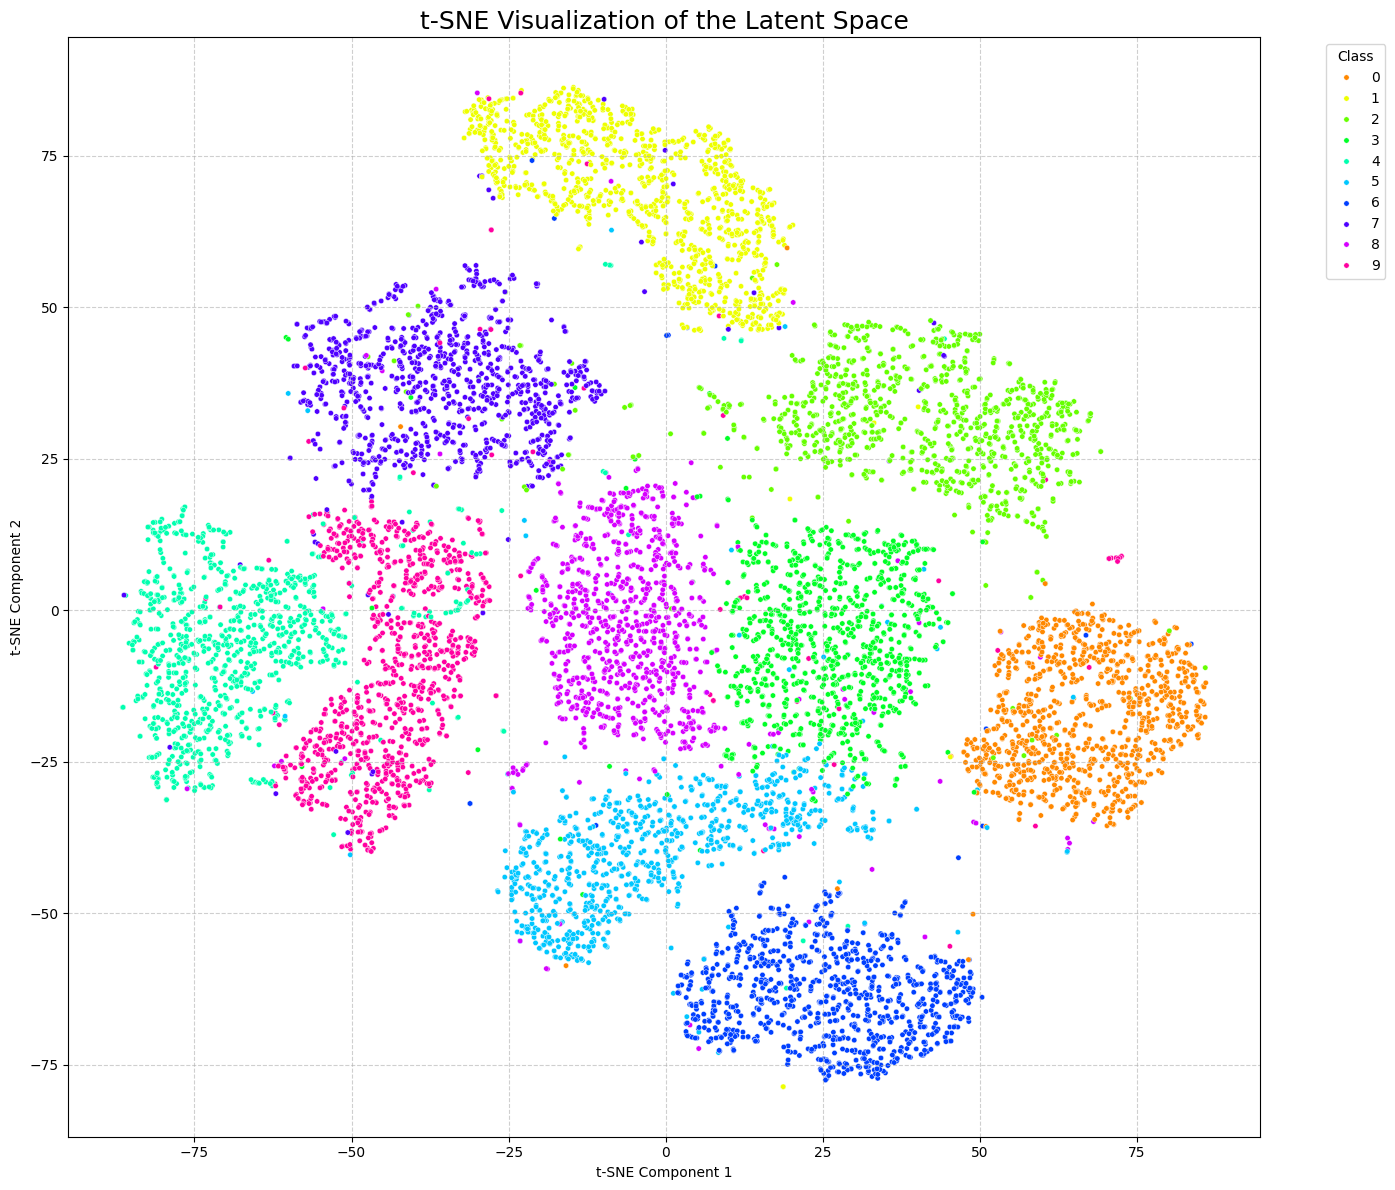

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 12))

# Get the class names from your dataset object for a readable legend
# If you don't have a dataset object with .class_names, you can create a list manually
# e.g., class_names = ["Class 0", "Class 1", ...]
if hasattr(test_ds, 'class_names'):
    class_names = test_ds.class_names
else: # For the original MNIST dataset
    class_names = [str(i) for i in range(10)]

num_classes = len(class_names)
palette = sns.color_palette("hsv", num_classes)

# Create the scatter plot, using the 'hue' parameter to color by class
scatter = sns.scatterplot(
    x=latent_space_2d[:, 0],
    y=latent_space_2d[:, 1],
    hue=all_labels,
    palette=palette,
    legend='full',
    s=15 # Adjust marker size if needed
)

# Create a legend with the actual class names
handles, _ = scatter.get_legend_handles_labels()
plt.legend(handles, class_names, title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('t-SNE Visualization of the Latent Space', fontsize=18)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Reconstruction plot

In [73]:
# def generate_and_plot_images(model, num_images_to_generate):
#     # Sample random points from the standard normal distribution (our prior p(z)).
#     random_latent_vectors = tf.random.normal(shape=(num_images_to_generate, model.q_z_xa_model.mu_z_layer.units))
    
#     # Use the generative decoder p(x|z) to generate images from these points.
#     generated_images = model.p_x_z_model(random_latent_vectors)
    
#     # Plot the results
#     plt.figure(figsize=(10, 10))
#     for i in range(num_images_to_generate):
#         plt.subplot(5, 5, i + 1)
#         plt.imshow(generated_images[i, :, :, 0], cmap='gray')
#         plt.axis('off')
#     plt.suptitle("Generated Digits from Latent Space", fontsize=16)
#     plt.show()

# # Generate 25 new images
# print("\nGenerating new images from the trained model...")
# generate_and_plot_images(adgm_model, 25)

In [77]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# --- Get latent vectors for the entire labeled set ---
print("Generating latent space representations for the MNIST test set...")
all_mu_z = []
all_labels = []

# --- THIS IS THE CORRECTED PART ---
# Iterate through the MNIST test_ds, not your custom labeled_dataset
for images, labels in test_ds:
    # Use the semi-supervised model's architecture
    shared_features = adgm.shared_encoder(images)
    mu_a = adgm.mu_a_layer(shared_features)
    mu_z, _ = adgm.q_z_xa_model([images, mu_a])
    
    all_mu_z.append(mu_z.numpy())
    all_labels.append(labels.numpy())

# The rest of the script remains the same
all_mu_z = np.concatenate(all_mu_z, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print(f"Generated {all_mu_z.shape[0]} latent vectors.")

# --- The rest of your code for calculating centroids is correct ---
print("Calculating centroids...")
num_classes = len(class_names)
latent_dim = all_mu_z.shape[1]
class_centroids = {}
for i in range(num_classes):
    class_mu_z = all_mu_z[all_labels == i]
    class_centroids[i] = np.mean(class_mu_z, axis=0)

print("Centroids calculated.")

Generating latent space representations for the MNIST test set...
Generated 10000 latent vectors.
Calculating centroids...
Centroids calculated.


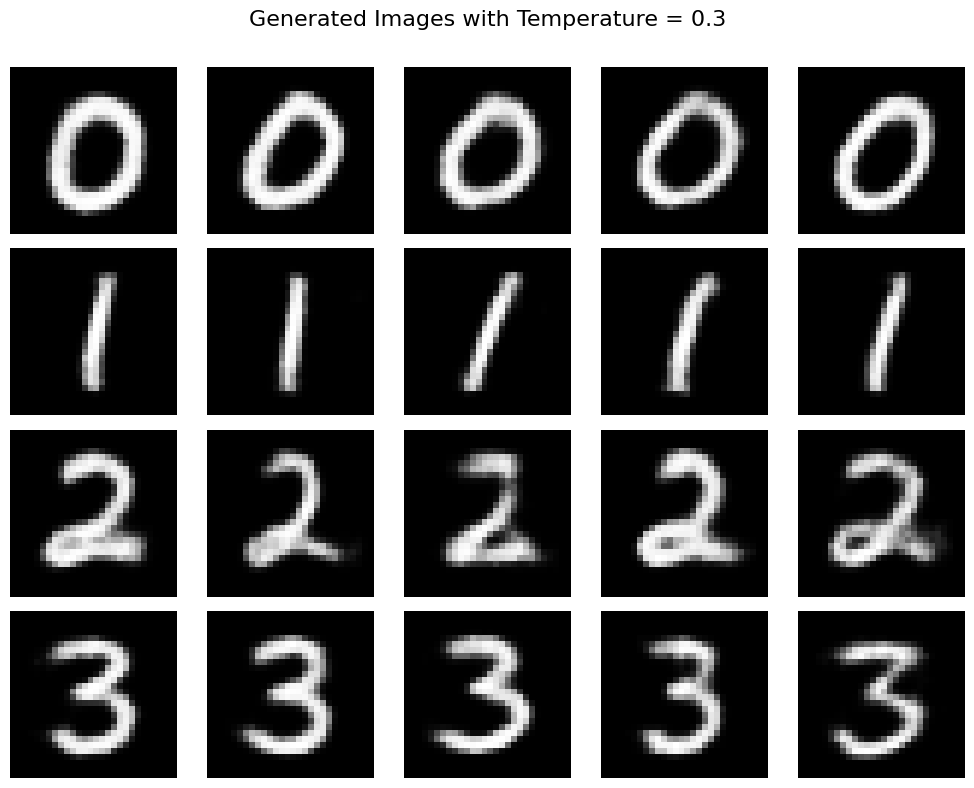

In [83]:
# --- Configuration for generation ---
# Adjust this value to control creativity
# 0.0 = no variation, 0.5 = low variation, 1.5 = high variation
temperature = 0.3
num_samples_per_class = 5

# --- Create the plot matrix ---
fig, axes = plt.subplots(num_classes, num_samples_per_class, figsize=(10, 2 * num_classes))
fig.suptitle(f'Generated Images with Temperature = {temperature}', fontsize=16)

for i, class_name in enumerate(class_names):
    centroid = class_centroids[i].reshape(1, latent_dim)
    
    # Set the y-label for the row to indicate the class
    axes[i, 0].set_ylabel(f'Class "{class_name}"', rotation=0, size='large', labelpad=40)
    
    for j in range(num_samples_per_class):
        # Generate random noise from a standard normal distribution
        epsilon = tf.random.normal(shape=(1, latent_dim))
        
        # Create a new sample by adding scaled noise to the centroid
        z_sample = centroid + temperature * epsilon
        
        # Generate an image from this new latent point
        generated_image_tensor = adgm.p_x_z_model(z_sample)
        generated_image = generated_image_tensor.numpy().reshape(28,28)
        
        # Plot the image
        ax = axes[i, j]
        ax.imshow(generated_image, cmap='gray')
        ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()